In [ ]:
"""
This file is the first file of my Quant Practice repo

This file is meant to go over the very basics of manual
minimzation and maximization optimization for functions f(x) or f(a, b) etc...

This is based on Prof. Chieh Wu's Machine Learning Course - lesson: Optimization P1

https://www.youtube.com/watch?v=4azqCkDHEtc&list=PLdk2fd27CQzQCoOj0YfBd4ECr76EqEXz4&index=8
"""

In [1]:
import numpy as np
from numpy import ones
from numpy import array
import matplotlib.pyplot as plt
from numpy import mean
import sympy as sp

In [2]:
a_sym, b_sym = sp.symbols('a b')
f_w = 5*a_sym**2 + 6*a_sym*b_sym - 16*a_sym + 3*b_sym**2 - 12*b_sym + 14
f_prime_w = sp.Matrix([sp.diff(f_w, a_sym), sp.diff(f_w, b_sym)])

In [3]:
def f(w):
    global fw
    a, b = w

    fw = 5*a*a + 6*a*b - 16*a + 3*b*b - 12*b + 14
    # f(w) = 5a^2 + 6ab - 16a + 3b^2 - 12b + 14

    return 5*a*a + 6*a*b - 16*a + 3*b*b - 12*b + 14

In [4]:
def f_prime_manual(w):
    A = np.array([[10.0, 6.0],
                  [6.0, 6.0]])
    c = np.array([16.0, 12.0])

    return A @ w - c

In [5]:
def f_prime_sp(w):
    a, b = map(float, w)
    deriv = f_prime_w.subs({a_sym: a, b_sym: b})

    return np.asarray(deriv, dtype=float).reshape(2,)

Best w = [0.9999136  1.00011987]
With an error of 1.829120499508008e-08


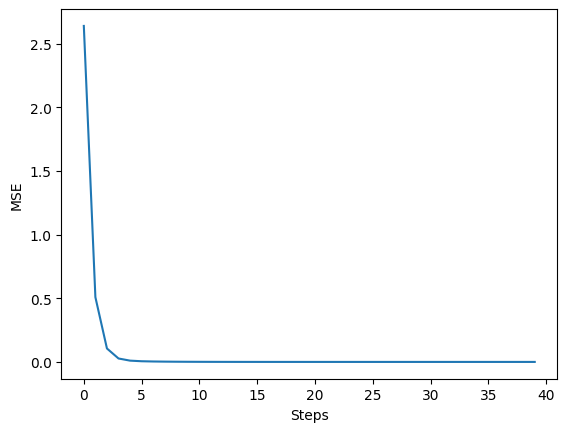

In [10]:
def min_f(f, steps=20):

    eta = 0.1
    f_value_list = []
    w = [2, 2]
    for i in range(steps):
        f_prime = f_prime_manual(w)
        w = w - eta * f_prime
        f_value_list.append(f(w))

    print(f"Best w = {w}")
    print(f"With an error of {f_value_list[steps-1]}")

    plt.plot(f_value_list)
    plt.xlabel('Steps')
    plt.ylabel('MSE')
    plt.show()

min_f(f, steps=40)


In [7]:
def g(w):
    x1 = np.array([0, 1])
    x2 = np.array([1, 1])
    y = np.array([0, 2])
    w = np.array([w[0], w[1]])

    result = 0.5 * (w.T @ x1 - y[0])**2 + 0.5 * (w.T @ x2 - y[1])**2
    return result

In [12]:
def g_prime(w):
    x1 = np.array([0, 1])
    x2 = np.array([1, 1])
    y = np.array([0, 2])

    w = np.array([w[0], w[1]])

    return x1 * (w.T @ x1 - y[0]) + x2 * (w.T @ x2 - y[1])

g_prime([1, 3])

array([2, 5])

Best w = [1.98179563 0.01125092]
With an error of 8.746686639861194e-05


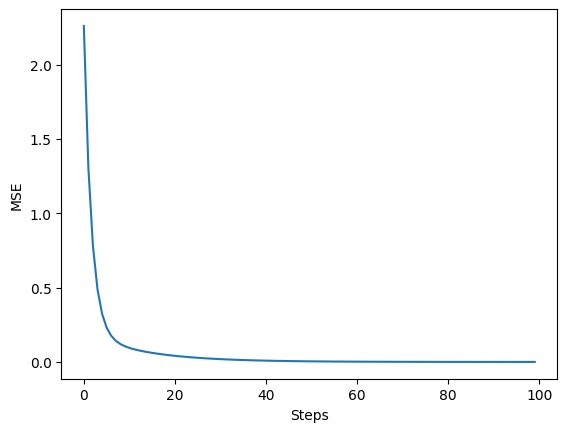

In [15]:
def min_g(g, steps=20, eta=0.1):
    g_val_list = []
    w = np.array([2, 2])
    for i in range(steps):
        g_prime_val = g_prime(w)
        w = w - eta * g_prime_val
        g_val_list.append(g(w))

    print(f"Best w = {w}")
    print(f"With an error of {g_val_list[steps-1]}")

    plt.plot(g_val_list)
    plt.xlabel('Steps')
    plt.ylabel('MSE')
    plt.show()

min_g(g, steps=100)